> **Note — notebook surface is moving.** Starting with `v0.4.0`, all notebooks
> in this repository will move to the dedicated
> [`forecastability-examples`](https://github.com/example/forecastability-examples)
> sibling repository. The library itself will keep only deterministic Python
> APIs, scripts under `scripts/`, and recipe pages under `docs/recipes/`.
> See [docs/plan/v0_4_0_examples_repo_split_ultimate_plan.md](../../docs/plan/v0_4_0_examples_repo_split_ultimate_plan.md).

# 📡 Exogenous Analysis — CrossAMI + pCrossAMI + Full Report

**Repo:** [AdamKrysztopa/dependence-forecastability](https://github.com/AdamKrysztopa/dependence-forecastability)
&nbsp;·&nbsp;
**Paper:** [arXiv:2601.10006](https://arxiv.org/abs/2601.10006)

---

## 1 · Introduction 🎓

### Dr. Peter Catt's *"The Knowable Future"* (arXiv:2601.10006)

[Peter Catt's landmark paper](https://arxiv.org/abs/2601.10006) introduced **AMI
(Average Mutual Information)** as a horizon-specific, model-free forecastability
diagnostic.  The idea is elegant: instead of the classical ACF (which assumes
linearity), measure *any* statistical dependence between the target at time $t$
and its own past at lag $h$:

$$\text{AMI}(h) = I(X_t ;\ X_{t-h})$$

This repository extends that framework in two dimensions:

### Extension 1 — CrossAMI: exogenous lead-lag diagnosis

**CrossAMI** measures the horizon-specific mutual information between an
*external driver* $Z$ (at time $t$) and a *target* $Y$ (at time $t+h$):

$$\text{CrossAMI}(h) = I(Y_{t+h} ;\ Z_t)$$

This answers the practical question: *"Does this sensor/covariate carry any
predictive signal for my target at horizon h?"*

### Extension 2 — pCrossAMI: direct vs mediated exogenous signal

**pCrossAMI** conditions out the intermediate target autocorrelation before
estimating the cross-MI.  It isolates whether the exogenous driver has
*direct, incremental* predictive value — value that a pure AR model cannot reproduce:

$$\text{pCrossAMI}(h) = I(\varepsilon_{t+h}^{(h)} ;\ Z_t)$$

where $\varepsilon^{(h)}$ are residuals from a horizon-specific *linear* regression on
the target. pCrossAMI removes the linear autoregressive component — if the
signal is entirely linear, pCrossAMI ≈ 0 (which is correct, not a failure).

### Operational definition of "forecastable"

> A series is **horizon-h forecastable** if the chosen dependence scorer
> (AMI or linear) at lag h exceeds the surrogate upper 95% band.
> For exogenous variables, CrossAMI exceeding the noise-control threshold indicates
> predictive signal from the driver at that horizon.

### Stationarity requirement

AMI/CrossAMI estimation assumes **stationarity**. For price series, always use
log-returns (or first-differences), not raw prices. The financial series in this
notebook are already in log-return form.

### Datasets in this notebook

| Pair | Target | Exogenous | Domain |
|------|--------|-----------|--------|
| `bike_cnt_temp` | Bike rentals / hr | Temperature | Urban mobility |
| `bike_cnt_hum` | Bike rentals / hr | Humidity | Urban mobility |
| `bike_cnt_noise` | Bike rentals / hr | White-noise control | Null-case |
| `aapl_spy` | AAPL log-returns | SPY log-returns | Equities |
| `btc_eth` | BTC log-returns | ETH log-returns | Crypto |

> **Disclosure:** CrossAMI and pCrossAMI are *project extensions*, not paper-native
> parity.  All diagnostics are computed on rolling training windows only — no
> look-ahead leakage.

## 2 · Setup & Installation ⚙️

```bash
# Install the package + notebook extras
uv sync --group notebook

# Register the kernel
uv run python -m ipykernel install --user --name forecastability
```

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import colors

import numpy as np
import pandas as pd
from pathlib import Path

mpl.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
        "figure.dpi": 120,
    }
)

print("Matplotlib configured.")

Matplotlib configured.


In [2]:
# Ensure we are always running from the project root,
# regardless of how the Jupyter kernel was started.
import os
from pathlib import Path as _P

_cwd = _P.cwd()
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
    print(f"Changed cwd → {_P.cwd()}")
else:
    print(f"cwd: {_cwd}")

Changed cwd → /Users/adamkrysztopa/projects/papers/ami


### Core imports from the `forecastability` package

In [3]:
# ── Core forecastability imports ─────────────────────────────────────────────
from forecastability import (
    ForecastabilityAnalyzerExog,
    ExogenousBenchmarkResult,
)
from forecastability.utils.config import ExogenousBenchmarkConfig, MetricConfig, RollingOriginConfig
from forecastability.pipeline import run_exogenous_rolling_origin_evaluation
from forecastability.pipeline.rolling_origin import build_expanding_window_splits

from forecastability.exog_benchmark import (
    load_benchmark_slice,
    build_case_summary,
    build_report_markdown,
)
from forecastability.utils.plots import plot_exog_benchmark_curves

print("All imports successful — package ready.")

All imports successful — package ready.


## 3 · Load Multivariate Example Data 📦

The repository ships with real-world data in `data/raw/`:

| File | Description |
|------|-------------|
| `exog/bike_sharing_hour.csv` | 17 379 hourly Bike-Sharing records (UCI) — columns: `cnt`, `temp`, `hum`, `windspeed` |
| `exog/spy_returns.csv` | S&P-500 ETF (SPY) daily log-returns |
| `exog/eth_returns.csv` | Ethereum (ETH) daily log-returns |
| `canonical/aapl_returns.csv` | Apple (AAPL) daily log-returns |
| `canonical/bitcoin_returns.csv` | Bitcoin (BTC) daily log-returns |

`load_benchmark_slice()` handles loading and length-alignment automatically.

In [4]:
DATA_ROOT = Path("data/raw")

# ── Bike-sharing ─────────────────────────────────────────────────────────────
bike = pd.read_csv(DATA_ROOT / "exog" / "bike_sharing_hour.csv")
bike_cnt = bike["cnt"].to_numpy(dtype=float)
bike_temp = bike["temp"].to_numpy(dtype=float)
bike_hum = bike["hum"].to_numpy(dtype=float)

# ── AAPL vs SPY ──────────────────────────────────────────────────────────────
aapl_df = pd.read_csv(DATA_ROOT / "canonical" / "aapl_returns.csv")
spy_df = pd.read_csv(DATA_ROOT / "exog" / "spy_returns.csv")
aapl = aapl_df["y"].to_numpy(dtype=float)
spy = spy_df["y"].to_numpy(dtype=float)
n_eq = min(len(aapl), len(spy))
aapl, spy = aapl[-n_eq:], spy[-n_eq:]

# ── BTC vs ETH ───────────────────────────────────────────────────────────────
btc_df = pd.read_csv(DATA_ROOT / "canonical" / "bitcoin_returns.csv")
eth_df = pd.read_csv(DATA_ROOT / "exog" / "eth_returns.csv")
btc = btc_df["y"].to_numpy(dtype=float)
eth = eth_df["y"].to_numpy(dtype=float)
n_cr = min(len(btc), len(eth))
btc, eth = btc[-n_cr:], eth[-n_cr:]

print(f"Bike-sharing   :  {len(bike_cnt):>6d} hourly observations")
print(f"AAPL / SPY     :  {len(aapl):>6d} daily observations (aligned tail)")
print(f"BTC / ETH      :  {len(btc):>6d} daily observations (aligned tail)")

Bike-sharing   :   17379 hourly observations
AAPL / SPY     :    6287 daily observations (aligned tail)
BTC / ETH      :    2608 daily observations (aligned tail)


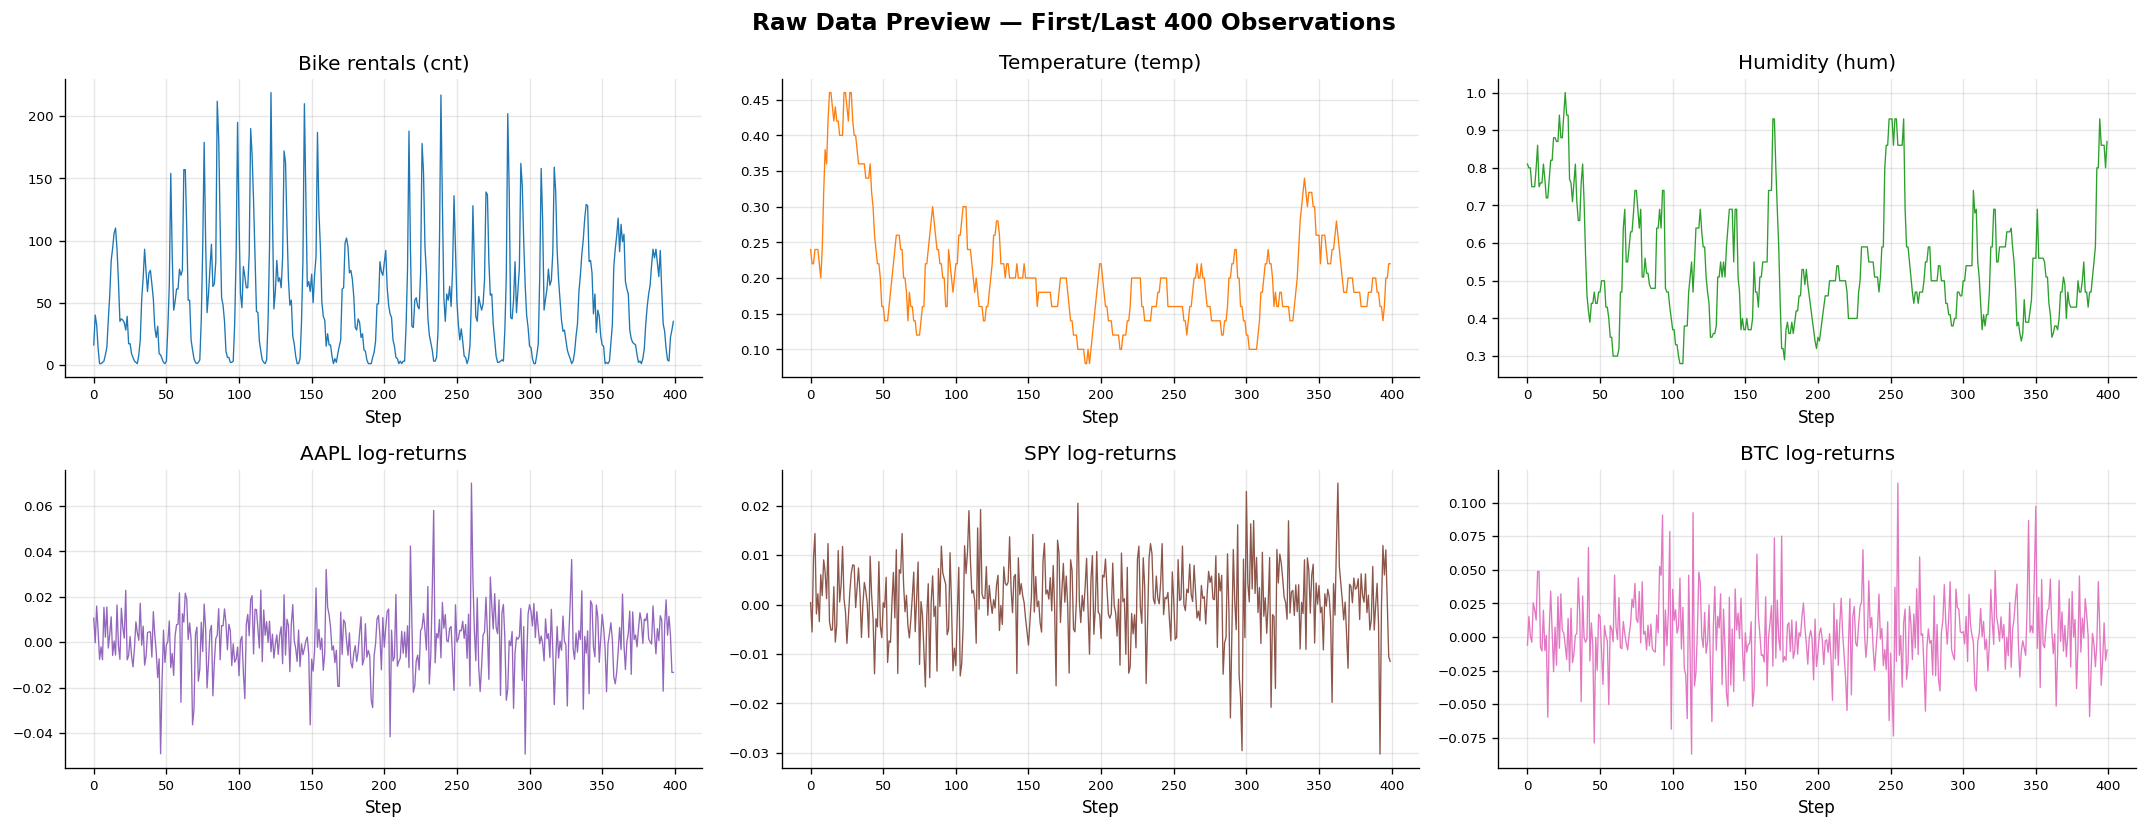

In [5]:
# ── Quick overview: first 400 steps ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 7))

axes[0, 0].plot(bike_cnt[:400], lw=0.8, color="#1f77b4")
axes[0, 0].set_title("Bike rentals (cnt)")
axes[0, 1].plot(bike_temp[:400], lw=0.8, color="#ff7f0e")
axes[0, 1].set_title("Temperature (temp)")
axes[0, 2].plot(bike_hum[:400], lw=0.8, color="#2ca02c")
axes[0, 2].set_title("Humidity (hum)")
axes[1, 0].plot(aapl[-400:], lw=0.8, color="#9467bd")
axes[1, 0].set_title("AAPL log-returns")
axes[1, 1].plot(spy[-400:], lw=0.8, color="#8c564b")
axes[1, 1].set_title("SPY log-returns")
axes[1, 2].plot(btc[-400:], lw=0.8, color="#e377c2")
axes[1, 2].set_title("BTC log-returns")

for ax in axes.flat:
    ax.set_xlabel("Step")
    ax.tick_params(labelsize=8)

fig.suptitle("Raw Data Preview — First/Last 400 Observations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · Configure and Run `ForecastabilityAnalyzerExog` ⚙️

`ForecastabilityAnalyzerExog` extends `ForecastabilityAnalyzer` with the optional
`exog=...` parameter.  Passing an exogenous array switches the analyzer into
**Cross-dependence mode**: it measures $I(Y_{t+h} ; Z_t)$ instead of $I(Y_t ; Y_{t-h})$.

```python
analyzer = ForecastabilityAnalyzerExog(n_surrogates=99, random_state=42)

# Raw CrossAMI: total lead-lag MI between exog (driver) and target
cross_raw = analyzer.compute_raw(
    target, max_lag=12, method="mi", exog=driver
)

# pCrossAMI: direct cross-MI after conditioning on AR target lags
cross_partial = analyzer.compute_partial(
    target, max_lag=12, method="mi", exog=driver
)
```

Below we run this manually on bike-sharing to see the raw curves, then use the
full rolling-origin pipeline for statistical robustness.

In [6]:
HORIZONS = [1, 2, 3, 4, 5, 6, 8, 12]
MAX_LAG = max(HORIZONS)

analyzer = ForecastabilityAnalyzerExog(n_surrogates=99, random_state=42)

# ── Bike cnt ~ Temperature ────────────────────────────────────────────────────
cross_raw_temp = analyzer.compute_raw(bike_cnt, max_lag=MAX_LAG, method="mi", exog=bike_temp)
cross_partial_temp = analyzer.compute_partial(
    bike_cnt, max_lag=MAX_LAG, method="mi", exog=bike_temp
)

# ── Bike cnt ~ Humidity ───────────────────────────────────────────────────────
cross_raw_hum = analyzer.compute_raw(bike_cnt, max_lag=MAX_LAG, method="mi", exog=bike_hum)
cross_partial_hum = analyzer.compute_partial(bike_cnt, max_lag=MAX_LAG, method="mi", exog=bike_hum)

# ── AAPL ~ SPY ────────────────────────────────────────────────────────────────
cross_raw_spy = analyzer.compute_raw(aapl, max_lag=MAX_LAG, method="mi", exog=spy)
cross_partial_spy = analyzer.compute_partial(aapl, max_lag=MAX_LAG, method="mi", exog=spy)

# ── BTC ~ ETH ─────────────────────────────────────────────────────────────────
cross_raw_eth = analyzer.compute_raw(btc, max_lag=MAX_LAG, method="mi", exog=eth)
cross_partial_eth = analyzer.compute_partial(btc, max_lag=MAX_LAG, method="mi", exog=eth)

lags = np.arange(1, MAX_LAG + 1)
print(f"CrossAMI computed for {MAX_LAG} horizons each.")
print(f"{'Pair':22s}  {'Raw h=1':>9s}  {'Direct h=1':>11s}  {'Ratio h=1':>10s}")
print("-" * 60)
for label, raw, partial in [
    ("bike_cnt ~ temp", cross_raw_temp, cross_partial_temp),
    ("bike_cnt ~ hum", cross_raw_hum, cross_partial_hum),
    ("aapl ~ spy", cross_raw_spy, cross_partial_spy),
    ("btc ~ eth", cross_raw_eth, cross_partial_eth),
]:
    ratio = float(partial[0]) / max(float(raw[0]), 1e-12)
    print(f"  {label:20s}  {raw[0]:9.4f}  {partial[0]:11.4f}  {ratio:10.3f}")

CrossAMI computed for 12 horizons each.
Pair                      Raw h=1   Direct h=1   Ratio h=1
------------------------------------------------------------
  bike_cnt ~ temp          0.1363       0.1363       1.000
  bike_cnt ~ hum           0.0839       0.0839       1.000
  aapl ~ spy               0.0135       0.0135       1.000
  btc ~ eth                0.0144       0.0144       1.000


## 5 · CrossAMI Horizon-Specific Curves 📈

Each point on the **CrossAMI** curve answers:
*"How much predictive information does the driver at time t carry about
the target h steps later?"*

The **pCrossAMI** (dashed) strips away the fraction that merely reflects the
target's own autocorrelation — isolating truly incremental exogenous signal.

> A large `CrossAMI − pCrossAMI` gap means the driver's apparent predictive
> power is largely a proxy for the target's own momentum, not genuine new information.

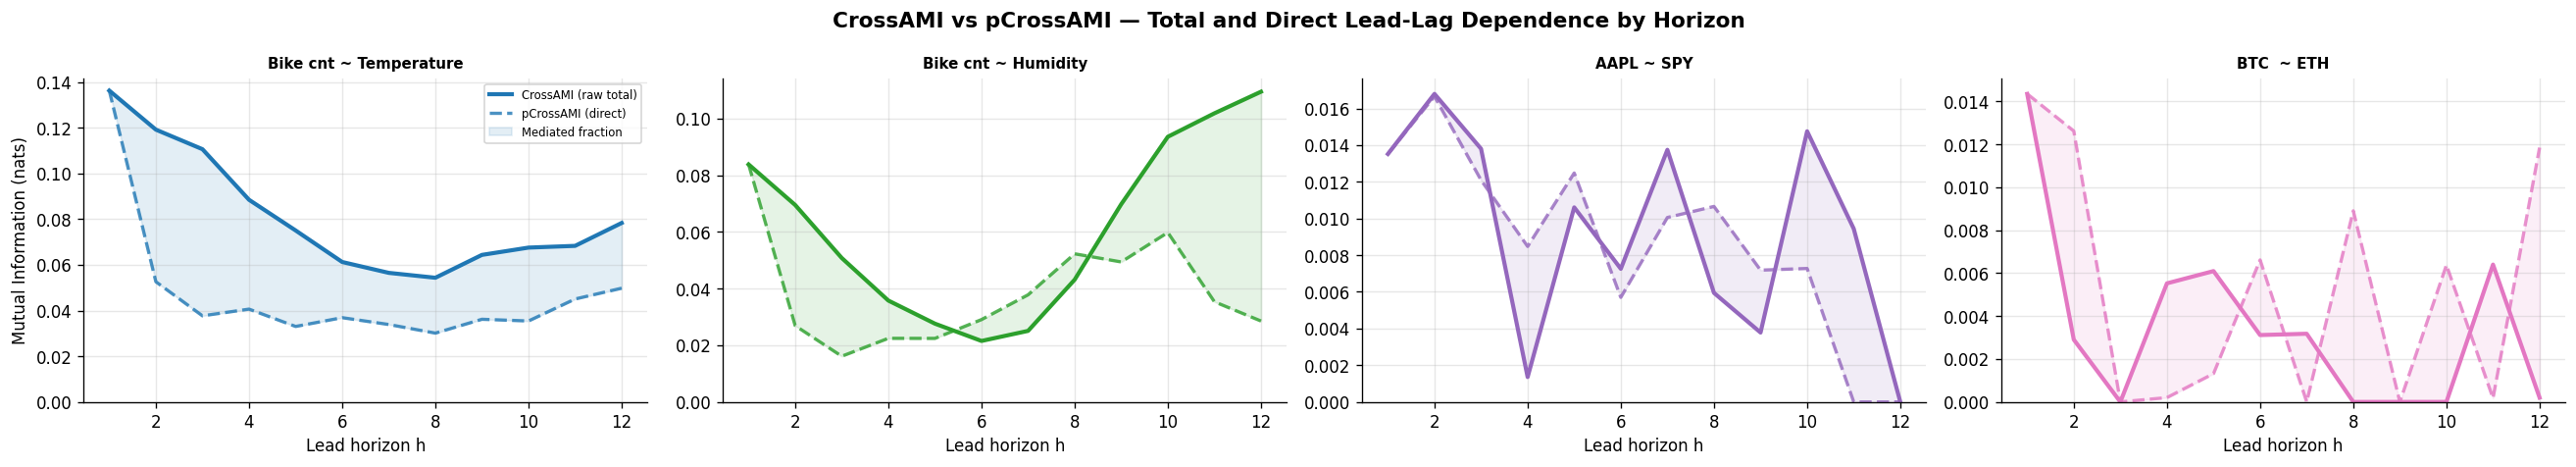

In [7]:
lags = np.arange(1, MAX_LAG + 1)
pairs = [
    ("Bike cnt ~ Temperature", cross_raw_temp, cross_partial_temp, "#1f77b4"),
    ("Bike cnt ~ Humidity", cross_raw_hum, cross_partial_hum, "#2ca02c"),
    ("AAPL ~ SPY", cross_raw_spy, cross_partial_spy, "#9467bd"),
    ("BTC  ~ ETH", cross_raw_eth, cross_partial_eth, "#e377c2"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, (label, raw, partial, color) in zip(axes, pairs):
    ax.plot(lags, raw, lw=2.5, color=color, label="CrossAMI (raw total)")
    ax.plot(lags, partial, lw=2.0, color=color, ls="--", alpha=0.8, label="pCrossAMI (direct)")
    ax.fill_between(lags, partial, raw, alpha=0.12, color=color, label="Mediated fraction")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("Lead horizon h")
    ax.set_ylim(bottom=0)

axes[0].set_ylabel("Mutual Information (nats)")
axes[0].legend(fontsize=7, loc="upper right")

fig.suptitle(
    "CrossAMI vs pCrossAMI — Total and Direct Lead-Lag Dependence by Horizon",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 5b · Production Pipeline — Rolling-Origin Evaluation 🔄

The single-pass curves above are computed on the full series.  For
**statistical robustness** the package uses *rolling-origin evaluation*:
the analysis is repeated over `n_origins` expanding training windows, and
results are averaged.  This guards against spurious signals from a single
window alignment.

`run_exogenous_rolling_origin_evaluation()` from `pipeline.py` wraps this loop.
`load_benchmark_slice()` from `exog_benchmark.py` loads and aligns data for all
seven pre-defined pairs (including noise controls).

In [8]:
# Configuration — mirrors configs/benchmark_exog_panel.yaml but inline
cfg = ExogenousBenchmarkConfig(
    rolling_origin=RollingOriginConfig(
        n_origins=5,  # fewer origins for notebook speed
        horizons=[1, 2, 3, 4, 5, 6, 8, 12],
    ),
    metric=MetricConfig(
        n_neighbors=8,
        min_pairs_ami=30,
        min_pairs_pami=50,
        n_surrogates=99,
        random_state=42,
    ),
)

print("ExogenousBenchmarkConfig built:")
print(f"  horizons   : {cfg.rolling_origin.horizons}")
print(f"  n_origins  : {cfg.rolling_origin.n_origins}")
print(f"  n_surrogates: {cfg.metric.n_surrogates}")
print(f"  project_extension: {cfg.project_extension}")

ExogenousBenchmarkConfig built:
  horizons   : [1, 2, 3, 4, 5, 6, 8, 12]
  n_origins  : 5
  n_surrogates: 99
  project_extension: True


In [9]:
# Load all seven benchmark pairs via the library loader
benchmark_cases = load_benchmark_slice(list(cfg.slice_case_ids))

print(f"Loaded {len(benchmark_cases)} benchmark cases:")
for case_id, target_name, exog_name, target_arr, exog_arr in benchmark_cases:
    print(f"  {case_id:25s}  target={target_name:8s}  exog={exog_name:8s}  n={len(target_arr)}")

Loaded 7 benchmark cases:
  bike_cnt_temp              target=bike_cnt  exog=temp      n=17379
  bike_cnt_hum               target=bike_cnt  exog=hum       n=17379
  bike_cnt_noise             target=bike_cnt  exog=noise     n=17379
  aapl_spy                   target=aapl      exog=spy       n=6287
  aapl_noise                 target=aapl      exog=noise     n=6287
  btc_eth                    target=btc       exog=eth       n=2608
  btc_noise                  target=btc       exog=noise     n=2608


In [10]:
# Run rolling-origin evaluation for all cases
# The loop takes ~2-4 minutes depending on your machine.
results: list[ExogenousBenchmarkResult] = []

for case_id, target_name, exog_name, target_arr, exog_arr in benchmark_cases:
    print(f"  Running {case_id} ...", end=" ", flush=True)
    result = run_exogenous_rolling_origin_evaluation(
        target_arr,
        exog_arr,
        case_id=case_id,
        target_name=target_name,
        exog_name=exog_name,
        horizons=cfg.rolling_origin.horizons,
        n_origins=cfg.rolling_origin.n_origins,
        random_state=cfg.metric.random_state,
        n_surrogates=cfg.metric.n_surrogates,
        min_pairs_raw=cfg.metric.min_pairs_ami,
        min_pairs_partial=cfg.metric.min_pairs_pami,
    )
    results.append(result)
    h1_raw = result.raw_cross_mi_by_horizon.get(1, float("nan"))
    print(f"done  (h=1 raw CrossAMI = {h1_raw:.4f})")

print(f"\nFinished {len(results)} cases.")

  Running bike_cnt_temp ... done  (h=1 raw CrossAMI = 0.1371)
  Running bike_cnt_hum ... done  (h=1 raw CrossAMI = 0.0855)
  Running bike_cnt_noise ... done  (h=1 raw CrossAMI = 0.0000)
  Running aapl_spy ... done  (h=1 raw CrossAMI = 0.0134)
  Running aapl_noise ... done  (h=1 raw CrossAMI = 0.0000)
  Running btc_eth ... done  (h=1 raw CrossAMI = 0.0137)
  Running btc_noise ... done  (h=1 raw CrossAMI = 0.0000)

Finished 7 cases.


## 6 · Build the Horizon Table and Generate Report 📄

`build_case_summary()` aggregates raw and conditioned metrics across all horizons,
producing one tidy row per (case, target, exogenous) pair.

`build_report_markdown()` compiles a full structured Markdown report with a
summary table and policy notes — ready for inclusion in a research document.

In [11]:
# Build horizon-level table from results
horizon_rows = []
for result in results:
    for horizon in result.horizons:
        horizon_rows.append(
            {
                "case_id": result.case_id,
                "target_name": result.target_name,
                "exog_name": result.exog_name,
                "horizon": horizon,
                "raw_cross_mi": result.raw_cross_mi_by_horizon[horizon],
                "conditioned_cross_mi": result.conditioned_cross_mi_by_horizon[horizon],
                "directness_ratio": result.directness_ratio_by_horizon[horizon],
                "origins_used": result.origins_used_by_horizon[horizon],
                "warning_directness_gt_one": int(horizon in result.warning_horizons),
            }
        )

horizon_table = pd.DataFrame(horizon_rows).sort_values(["case_id", "horizon"])
print(f"Horizon table: {len(horizon_table)} rows  x  {len(horizon_table.columns)} columns")
horizon_table.head(10)

Horizon table: 56 rows  x  9 columns


,case_id,target_name,exog_name,horizon,raw_cross_mi,conditioned_cross_mi,directness_ratio,origins_used,warning_directness_gt_one
32,aapl_noise,aapl,noise,1,0.000000,0.000000,0.000000e+00,5,0
33,aapl_noise,aapl,noise,2,0.000000,0.000000,0.000000e+00,5,0
34,aapl_noise,aapl,noise,3,0.004866,0.001266,2.601734e-01,5,0
35,aapl_noise,aapl,noise,4,0.000000,0.007460,7.460371e+09,5,1
36,aapl_noise,aapl,noise,5,0.004527,0.000264,5.821704e-02,5,0
37,aapl_noise,aapl,noise,6,0.000000,0.000000,0.000000e+00,5,0
38,aapl_noise,aapl,noise,8,0.000000,0.000906,9.063266e+08,5,1
39,aapl_noise,aapl,noise,12,0.000290,0.000000,0.000000e+00,5,0
24,aapl_spy,aapl,spy,1,0.013383,0.013383,1.000000e+00,5,0
25,aapl_spy,aapl,spy,2,0.016958,0.016462,9.707690e-01,5,0


In [12]:
# Case-level summary
summary_table = build_case_summary(horizon_table)
summary_table

,case_id,target_name,exog_name,mean_raw_cross_mi,mean_conditioned_cross_mi,mean_directness_ratio,warning_horizon_count,warning_note
0,aapl_noise,aapl,noise,0.001210,0.001237,1.045837e+09,2,Warning only: conditioned signal exceeded raw ...
1,aapl_spy,aapl,spy,0.008950,0.009837,1.433409e+00,3,Warning only: conditioned signal exceeded raw ...
2,bike_cnt_hum,bike_cnt,hum,0.055271,0.034967,7.442448e-01,2,Warning only: conditioned signal exceeded raw ...
3,bike_cnt_noise,bike_cnt,noise,0.001627,0.002392,9.571663e+08,4,Warning only: conditioned signal exceeded raw ...
4,bike_cnt_temp,bike_cnt,temp,0.090227,0.052227,5.591592e-01,0,No directness warnings.
5,btc_eth,btc,eth,0.004238,0.006497,1.237745e+09,4,Warning only: conditioned signal exceeded raw ...
6,btc_noise,btc,noise,0.000593,0.001347,8.968597e+07,2,Warning only: conditioned signal exceeded raw ...


In [13]:
# Generate full Markdown report
from IPython.display import Markdown, display

report_md = build_report_markdown(summary_table, cfg)
display(Markdown(report_md))

# Exogenous Benchmark Slice

> Disclosure: exogenous cross-dependence and conditioned pCrossAMI reporting are project extensions, not paper-native parity.

This workflow is intended as both descriptive analysis and bounded model-selection guidance.
Raw CrossMI describes total lagged target-exogenous dependence; conditioned pCrossAMI isolates direct dependence after conditioning on intermediate target lags.
All exogenous diagnostics are computed on train windows only inside rolling-origin evaluation.

- Analysis scope: `both`
- Project extension: `True`
- Cases: bike_cnt_temp, bike_cnt_hum, bike_cnt_noise, aapl_spy, aapl_noise, btc_eth, btc_noise

## Case Summary

| Case | Mean Raw CrossMI | Mean Conditioned pCrossAMI | Mean Directness Ratio | Warning |
|---|---:|---:|---:|---|
| aapl_noise | 0.0012 | 0.0012 | 1045837237.4974 | Warning only: conditioned signal exceeded raw on at least one horizon. |
| aapl_spy | 0.0090 | 0.0098 | 1.4334 | Warning only: conditioned signal exceeded raw on at least one horizon. |
| bike_cnt_hum | 0.0553 | 0.0350 | 0.7442 | Warning only: conditioned signal exceeded raw on at least one horizon. |
| bike_cnt_noise | 0.0016 | 0.0024 | 957166320.3210 | Warning only: conditioned signal exceeded raw on at least one horizon. |
| bike_cnt_temp | 0.0902 | 0.0522 | 0.5592 | No directness warnings. |
| btc_eth | 0.0042 | 0.0065 | 1237744534.7329 | Warning only: conditioned signal exceeded raw on at least one horizon. |
| btc_noise | 0.0006 | 0.0013 | 89685973.1308 | Warning only: conditioned signal exceeded raw on at least one horizon. |

Warning policy: any `directness_ratio > 1.0` is reported as a numerical/estimation warning, not a scientific conclusion.

## 7 · Visualizations 🎨

### 7a — Raw vs Conditioned CrossAMI per case (library plot)

`plot_exog_benchmark_curves()` from `plots.py` renders one panel per case showing
both the **raw CrossAMI** and the **conditioned pCrossAMI** horizon curves, with
orange dots marking any `directness_ratio > 1` warnings.

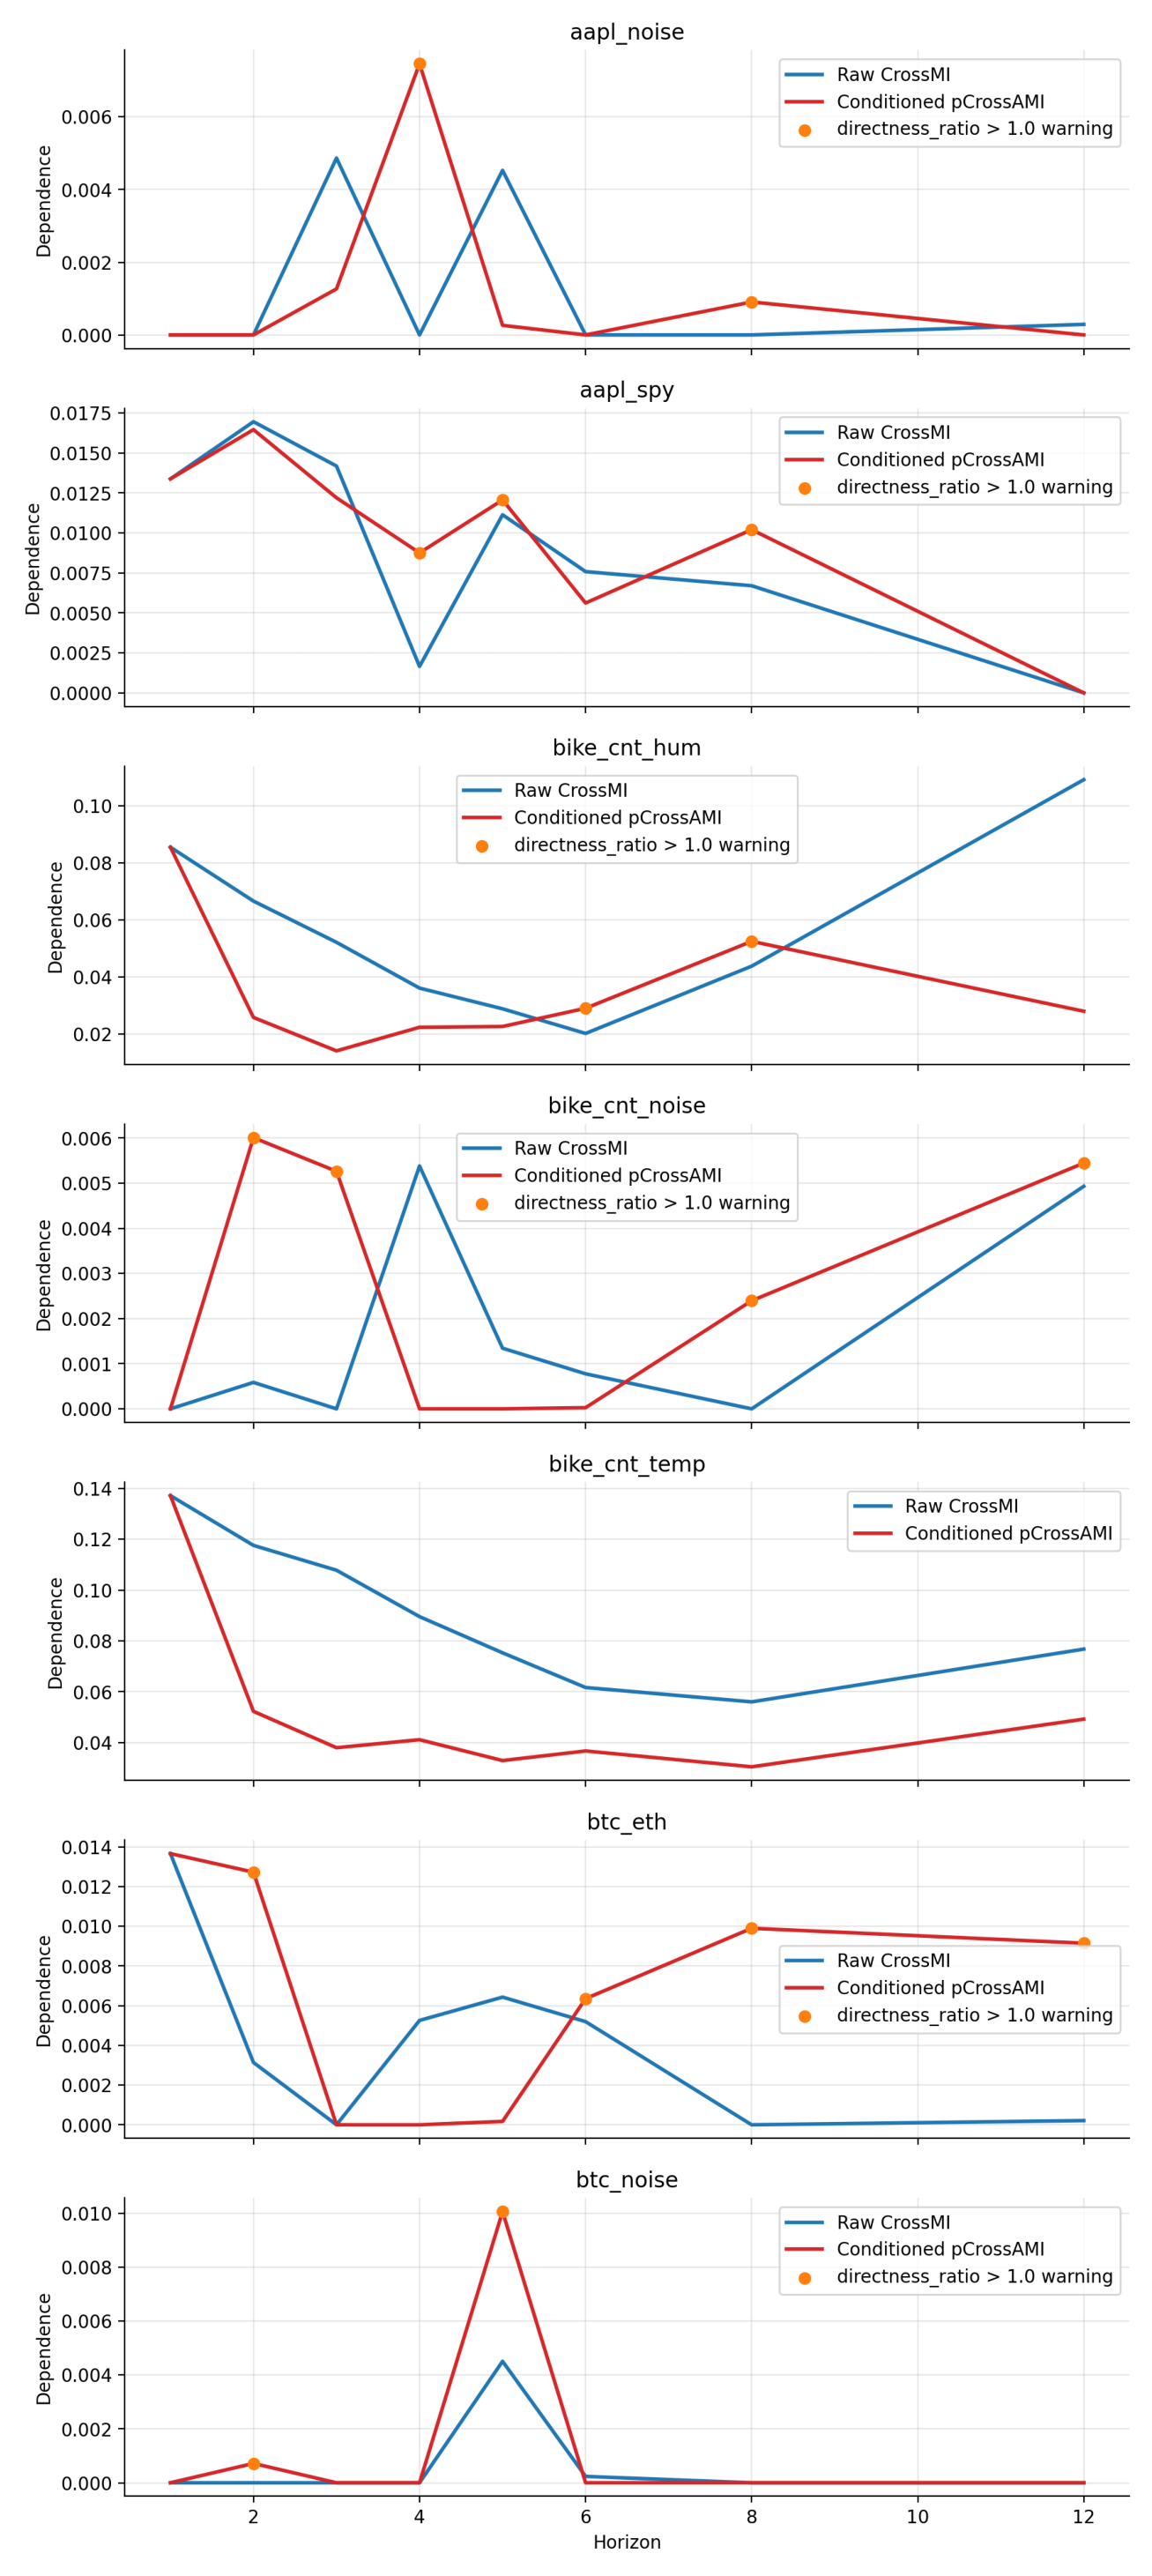

In [14]:
import tempfile

fig_path = Path(tempfile.mkdtemp()) / "raw_vs_conditioned.png"
plot_exog_benchmark_curves(horizon_table, save_path=fig_path)

# Show inline
img = plt.imread(str(fig_path))
fig_disp, ax_disp = plt.subplots(figsize=(11, max(4, 3.5 * len(results))))
ax_disp.imshow(img)
ax_disp.axis("off")
plt.tight_layout()
plt.show()

### 7b — Driver Ranking Heatmap (mean CrossAMI × horizon)

A heatmap is the clearest way to rank drivers by their mean predictive signal
at each forecast horizon.  Bright cells = high CrossAMI = strong lead-lag signal.

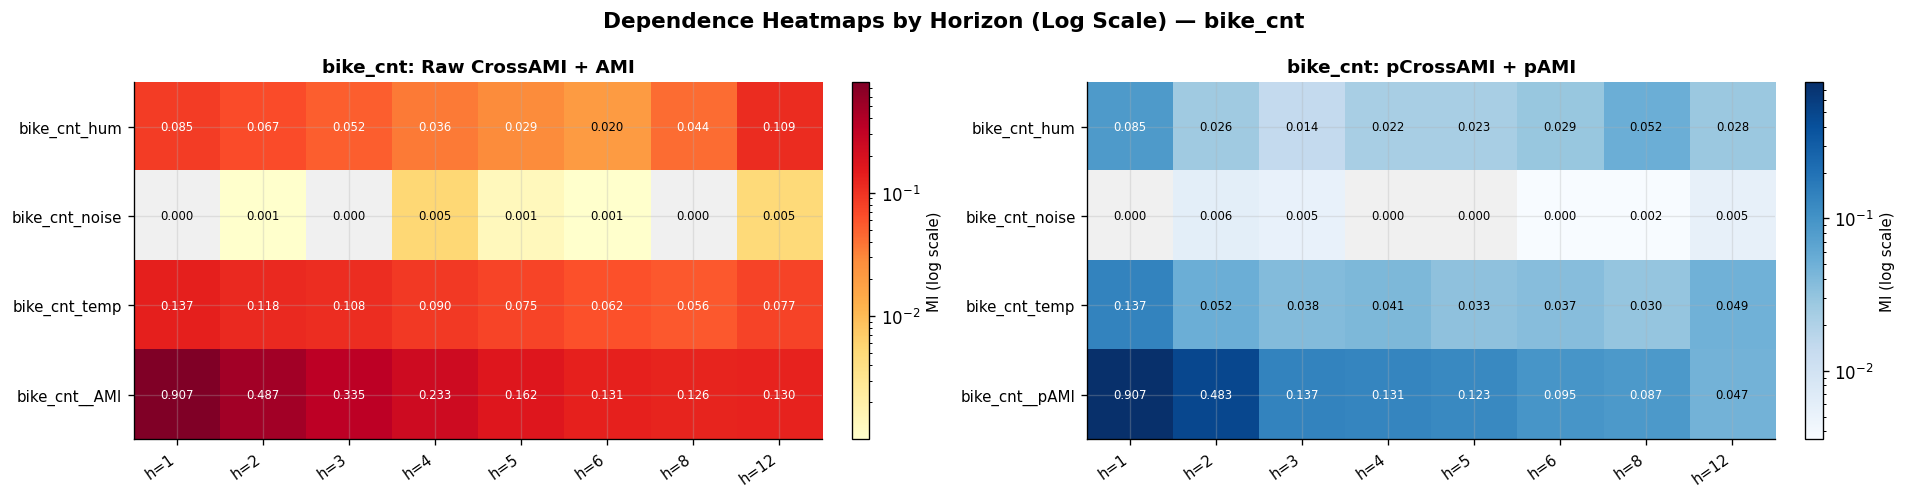

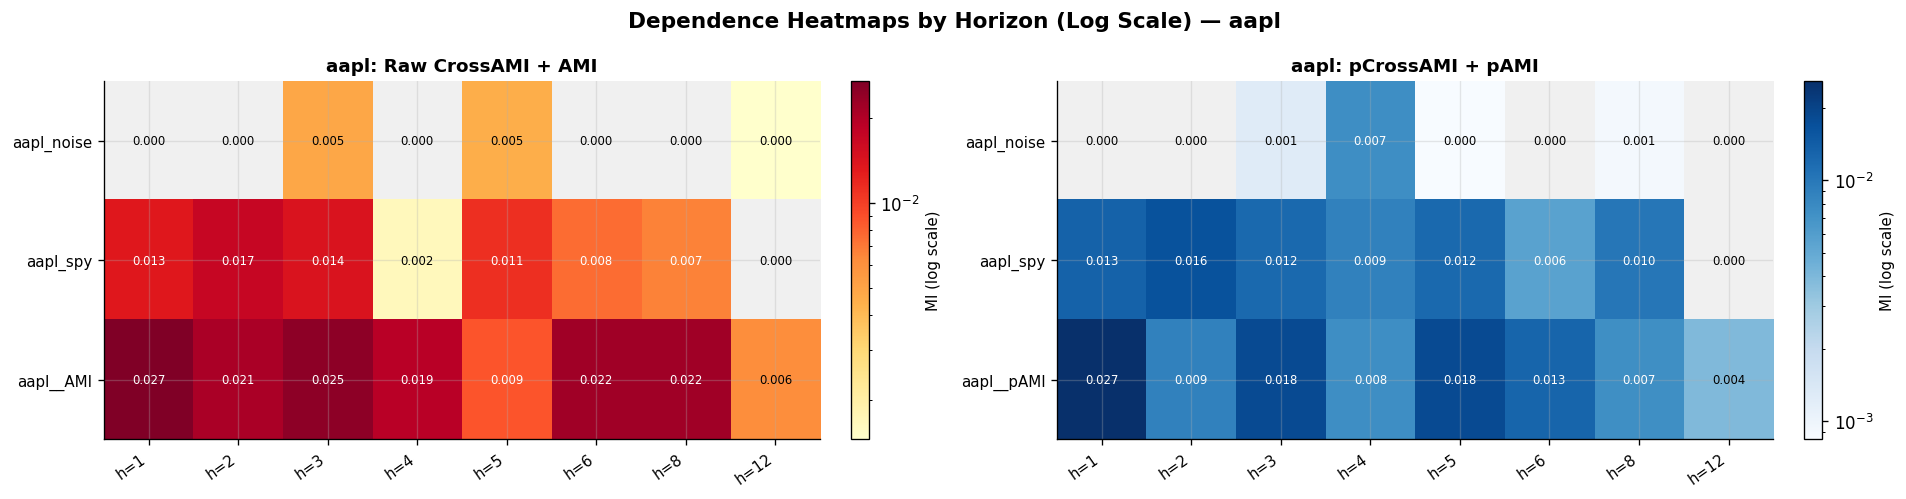

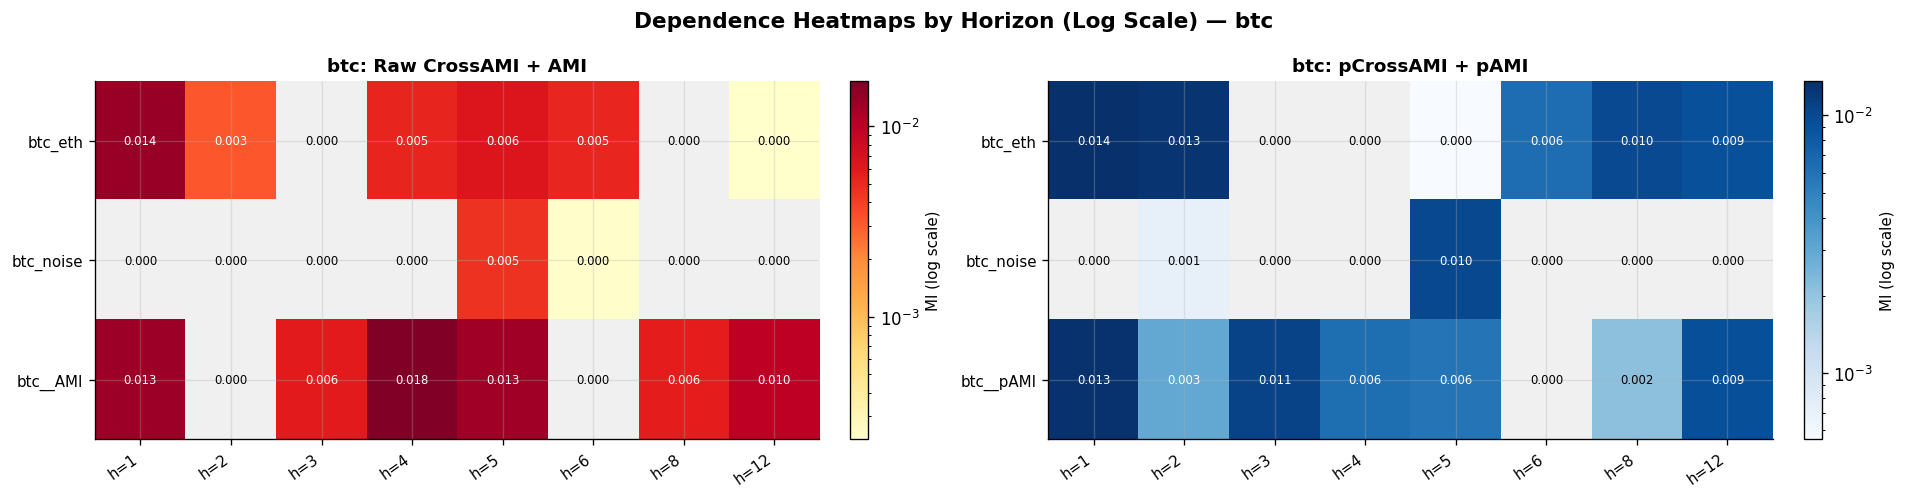

In [15]:
# ------------------------------------------------------------------
# 1) Compute target-only AMI/pAMI baselines (train-window only)
# ------------------------------------------------------------------
def compute_target_auto_by_horizon(
    target: np.ndarray,
    horizons: list[int],
    n_origins: int,
    random_state: int,
    min_pairs_raw: int,
    min_pairs_partial: int,
    n_surrogates: int,
) -> tuple[dict[int, float], dict[int, float]]:
    ami_by_h, pami_by_h = {}, {}

    for h in horizons:
        try:
            splits = build_expanding_window_splits(target, n_origins=n_origins, horizon=h)
        except ValueError:
            continue

        ami_vals, pami_vals = [], []
        for idx, split in enumerate(splits):
            analyzer = ForecastabilityAnalyzerExog(
                n_surrogates=n_surrogates,
                random_state=random_state + (1000 * h) + idx,
            )
            train_target = split.train

            # exog=None => AutoMI / pAutoMI
            ami_curve = analyzer.compute_raw(
                train_target,
                max_lag=h,
                method="mi",
                min_pairs=min_pairs_raw,
                exog=None,
            )
            pami_curve = analyzer.compute_partial(
                train_target,
                max_lag=h,
                method="mi",
                min_pairs=min_pairs_partial,
                exog=None,
            )
            ami_vals.append(float(ami_curve[h - 1]))
            pami_vals.append(float(pami_curve[h - 1]))

        if ami_vals:
            ami_by_h[h] = float(np.mean(ami_vals))
        if pami_vals:
            pami_by_h[h] = float(np.mean(pami_vals))

    return ami_by_h, pami_by_h


target_series_by_name = {}
for _, target_name, _, target_arr, _ in benchmark_cases:
    target_series_by_name.setdefault(target_name, target_arr)

target_ami_by_name, target_pami_by_name = {}, {}
for tname, tarr in target_series_by_name.items():
    ami_h, pami_h = compute_target_auto_by_horizon(
        target=tarr,
        horizons=cfg.rolling_origin.horizons,
        n_origins=cfg.rolling_origin.n_origins,
        random_state=cfg.metric.random_state,
        min_pairs_raw=cfg.metric.min_pairs_ami,
        min_pairs_partial=cfg.metric.min_pairs_pami,
        n_surrogates=cfg.metric.n_surrogates,
    )
    target_ami_by_name[tname] = ami_h
    target_pami_by_name[tname] = pami_h


# ------------------------------------------------------------------
# 2) Plot one heatmap pair (raw / conditioned) per target
#    with LogNorm scaling
# ------------------------------------------------------------------
targets_in_order = list(dict.fromkeys([r.target_name for r in results]))

for target_name in targets_in_order:
    case_ids = [r.case_id for r in results if r.target_name == target_name]
    sub = horizon_table[horizon_table["case_id"].isin(case_ids)].copy()

    pivot_raw = sub.pivot_table(
        index="case_id",
        columns="horizon",
        values="raw_cross_mi",
        aggfunc="mean",
    ).sort_index()

    pivot_cond = sub.pivot_table(
        index="case_id",
        columns="horizon",
        values="conditioned_cross_mi",
        aggfunc="mean",
    ).sort_index()

    hs = list(pivot_raw.columns)

    # Add target auto baselines as extra rows
    pivot_raw.loc[f"{target_name}__AMI"] = [
        target_ami_by_name[target_name].get(h, np.nan) for h in hs
    ]
    pivot_cond.loc[f"{target_name}__pAMI"] = [
        target_pami_by_name[target_name].get(h, np.nan) for h in hs
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4.2, 0.52 * len(pivot_raw.index) + 2.0)))

    for ax, pivot, title, cmap_name in [
        (axes[0], pivot_raw, f"{target_name}: Raw CrossAMI + AMI", "YlOrRd"),
        (axes[1], pivot_cond, f"{target_name}: pCrossAMI + pAMI", "Blues"),
    ]:
        arr = pivot.values.astype(float)

        # Log scale needs strictly positive values; mask non-positive / NaN
        arr_plot = arr.copy()
        arr_plot[~np.isfinite(arr_plot)] = np.nan
        arr_plot[arr_plot <= 0] = np.nan

        finite_pos = arr_plot[np.isfinite(arr_plot)]
        if finite_pos.size == 0:
            norm = None
            vmin_mid = None
        else:
            vmin = max(np.nanpercentile(finite_pos, 5), 1e-6)
            vmax = max(np.nanpercentile(finite_pos, 99), vmin * 1.01)
            norm = colors.LogNorm(vmin=vmin, vmax=vmax)
            vmin_mid = np.sqrt(vmin * vmax)

        cmap = plt.get_cmap(cmap_name).copy()
        cmap.set_bad(color="#f0f0f0")  # color for NaN / <=0 cells

        im = ax.imshow(arr_plot, aspect="auto", cmap=cmap, interpolation="nearest", norm=norm)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"h={h}" for h in pivot.columns], rotation=35, ha="right", fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=9)
        ax.set_title(title, fontweight="bold", fontsize=11)

        cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
        cbar.set_label("MI (log scale)", fontsize=9)

        # numeric labels
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                v = arr[i, j]
                if not np.isfinite(v):
                    txt, txt_color = "—", "black"
                else:
                    txt = f"{v:.3f}"
                    if v <= 0 or vmin_mid is None:
                        txt_color = "black"
                    else:
                        txt_color = "white" if v > vmin_mid else "black"
                ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=txt_color)

    fig.suptitle(
        f"Dependence Heatmaps by Horizon (Log Scale) — {target_name}",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

### 7c — Directness Ratio Profile

The **Directness Ratio** = pCrossAMI / CrossAMI measures how much of the
apparent exogenous signal survives conditioning on the target's own history.

- **Ratio ≈ 1.0** → the driver adds *unique, direct* predictive value
- **Ratio ≈ 0.0** → the driver is largely redundant to the target's own momentum
- **Ratio > 1.0** → ARCH / volatility amplification warning (numerical artefact)

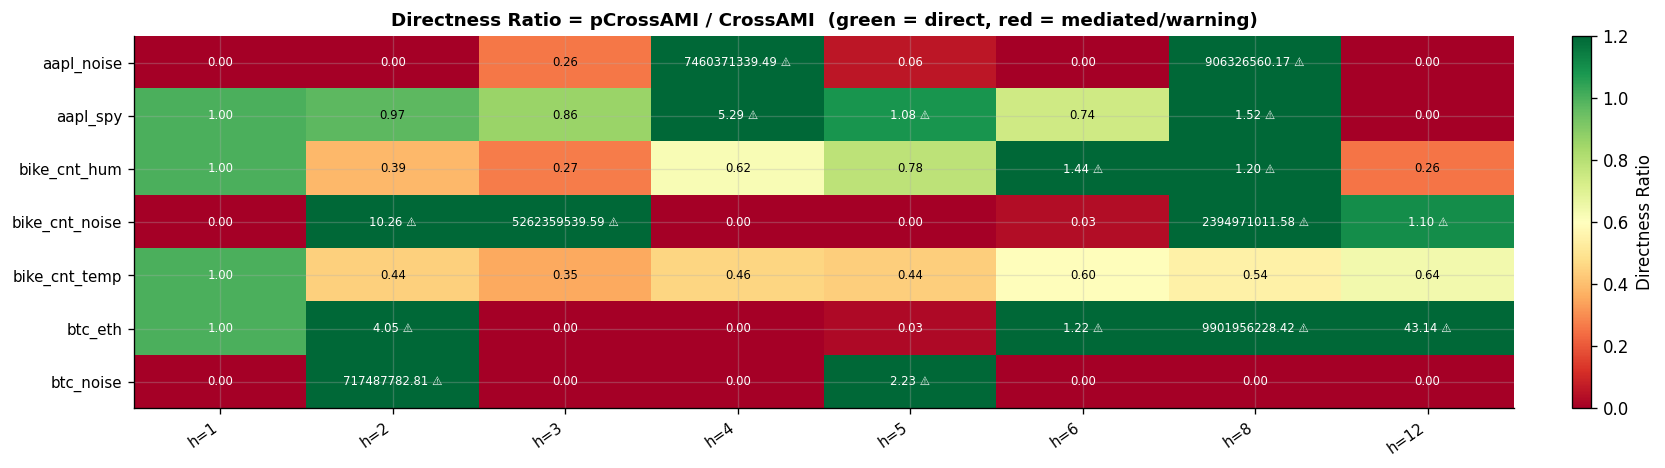

In [16]:
pivot_dr = horizon_table.pivot_table(
    index="case_id", columns="horizon", values="directness_ratio", aggfunc="mean"
)

# Clamp for display (ratio > 1 are warnings, not scientific conclusions)
pivot_dr_clipped = pivot_dr.clip(upper=1.5)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(
    pivot_dr_clipped.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1.2, interpolation="nearest"
)
ax.set_xticks(range(len(pivot_dr.columns)))
ax.set_xticklabels([f"h={h}" for h in pivot_dr.columns], rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_dr.index)))
ax.set_yticklabels(pivot_dr.index, fontsize=9)
ax.set_title(
    "Directness Ratio = pCrossAMI / CrossAMI  (green = direct, red = mediated/warning)",
    fontweight="bold",
    fontsize=11,
)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.04, label="Directness Ratio")
for i in range(len(pivot_dr.index)):
    for j in range(len(pivot_dr.columns)):
        val = pivot_dr.values[i, j]
        label = f"{val:.2f}" + (" ⚠" if val > 1.0 else "")
        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=7,
            color="black" if 0.2 < val < 1.0 else "white",
        )

plt.tight_layout()
plt.show()

### 7d — Top-driver bar chart: mean CrossAMI across all horizons

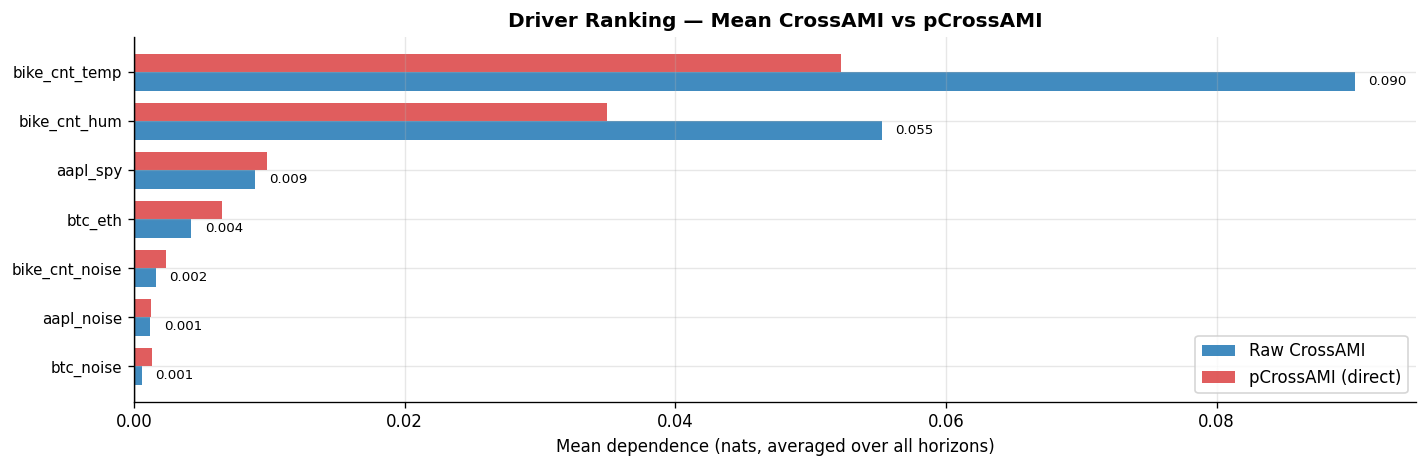

In [17]:
driver_mean = (
    horizon_table.groupby(["case_id", "exog_name"])[["raw_cross_mi", "conditioned_cross_mi"]]
    .mean()
    .reset_index()
    .sort_values("raw_cross_mi", ascending=True)
)

x = np.arange(len(driver_mean))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4))
bars_raw = ax.barh(
    x - w / 2, driver_mean["raw_cross_mi"], w, label="Raw CrossAMI", color="#1f77b4", alpha=0.85
)
bars_cond = ax.barh(
    x + w / 2,
    driver_mean["conditioned_cross_mi"],
    w,
    label="pCrossAMI (direct)",
    color="#d62728",
    alpha=0.75,
)
ax.set_yticks(x)
ax.set_yticklabels(driver_mean["case_id"], fontsize=9)
ax.set_xlabel("Mean dependence (nats, averaged over all horizons)")
ax.set_title("Driver Ranking — Mean CrossAMI vs pCrossAMI", fontweight="bold", fontsize=12)
ax.legend()
ax.axvline(0, color="black", lw=0.8)

# Annotate values
for bar in bars_raw:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

### 7e — Decay curve comparison: real vs noise control (with target AMI baseline)

The *noise control* cases (bike_cnt_noise, aapl_noise, btc_noise) use a
synthetic white-noise exogenous series, so their CrossAMI should remain near zero
across horizons and provide an empirical false-positive baseline.

We now also overlay the target’s own AMI (computed horizon-wise on rolling train
windows only). This helps separate:

- Driver signal: CrossAMI above noise and meaningfully aligned with target AMI
- Weak exogenous value: CrossAMI close to noise and/or far below target AMI

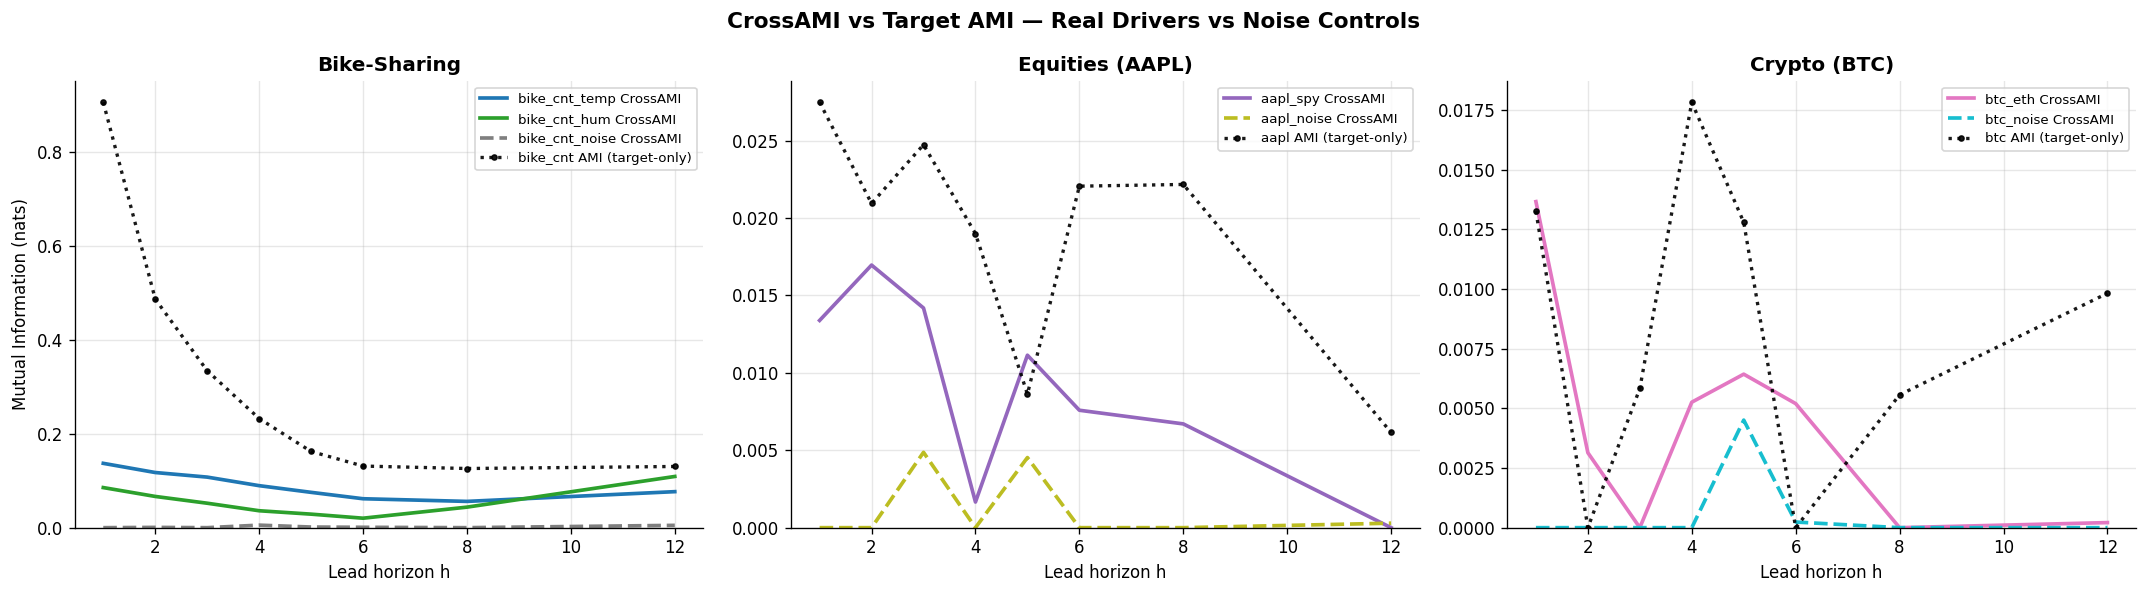

In [18]:
COLOR_MAP = {
    "bike_cnt_temp": "#1f77b4",
    "bike_cnt_hum": "#2ca02c",
    "bike_cnt_noise": "#7f7f7f",
    "aapl_spy": "#9467bd",
    "aapl_noise": "#bcbd22",
    "btc_eth": "#e377c2",
    "btc_noise": "#17becf",
}
LINE_STYLES = {case_id: ("--" if "noise" in case_id else "-") for case_id in COLOR_MAP}

groups = {
    "Bike-Sharing": ["bike_cnt_temp", "bike_cnt_hum", "bike_cnt_noise"],
    "Equities (AAPL)": ["aapl_spy", "aapl_noise"],
    "Crypto (BTC)": ["btc_eth", "btc_noise"],
}

# ------------------------------------------------------------------
# Build target-only AMI baselines (train-window only, horizon-specific)
# ------------------------------------------------------------------
result_by_case = {r.case_id: r for r in results}

target_series_by_name = {}
for _, target_name, _, target_arr, _ in benchmark_cases:
    target_series_by_name.setdefault(target_name, target_arr)


def compute_target_ami_by_horizon(
    target: np.ndarray,
    horizons: list[int],
    n_origins: int,
    random_state: int,
    min_pairs_raw: int,
    n_surrogates: int,
) -> dict[int, float]:
    ami_by_h = {}
    for h in horizons:
        try:
            splits = build_expanding_window_splits(target, n_origins=n_origins, horizon=h)
        except ValueError:
            continue

        vals = []
        for idx, split in enumerate(splits):
            train_target = split.train
            analyzer = ForecastabilityAnalyzerExog(
                n_surrogates=n_surrogates,
                random_state=random_state + (1000 * h) + idx,
            )
            # exog=None => AutoMI (AMI)
            ami_curve = analyzer.compute_raw(
                train_target,
                max_lag=h,
                method="mi",
                min_pairs=min_pairs_raw,
                exog=None,
            )
            vals.append(float(ami_curve[h - 1]))

        if vals:
            ami_by_h[h] = float(np.mean(vals))
    return ami_by_h


target_ami_by_name = {
    tname: compute_target_ami_by_horizon(
        target=tarr,
        horizons=cfg.rolling_origin.horizons,
        n_origins=cfg.rolling_origin.n_origins,
        random_state=cfg.metric.random_state,
        min_pairs_raw=cfg.metric.min_pairs_ami,
        n_surrogates=cfg.metric.n_surrogates,
    )
    for tname, tarr in target_series_by_name.items()
}

# ------------------------------------------------------------------
# Plot: CrossAMI curves + target AMI baseline in each panel
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, cases) in zip(axes, groups.items()):
    # CrossAMI for each case
    for case_id in cases:
        result = result_by_case[case_id]
        hs = sorted(result.raw_cross_mi_by_horizon)
        vals = [result.raw_cross_mi_by_horizon[h] for h in hs]
        ax.plot(
            hs,
            vals,
            lw=2.2,
            color=COLOR_MAP.get(case_id, "grey"),
            ls=LINE_STYLES.get(case_id, "-"),
            label=f"{case_id} CrossAMI",
        )

    # One target AMI baseline per panel (all cases in a panel share target)
    panel_target_name = result_by_case[cases[0]].target_name
    ami_curve = target_ami_by_name.get(panel_target_name, {})
    if ami_curve:
        hs_ami = sorted(ami_curve)
        vals_ami = [ami_curve[h] for h in hs_ami]
        ax.plot(
            hs_ami,
            vals_ami,
            lw=2.0,
            color="black",
            ls=":",
            marker="o",
            ms=3,
            alpha=0.9,
            label=f"{panel_target_name} AMI (target-only)",
        )

    ax.set_title(group_name, fontweight="bold")
    ax.set_xlabel("Lead horizon h")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Mutual Information (nats)")
fig.suptitle(
    "CrossAMI vs Target AMI — Real Drivers vs Noise Controls",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### What CrossAMI + pCrossAMI tell us

The triage logic is simple but powerful:

| Observation | Action |
|-------------|--------|
| CrossAMI >> noise floor **and** pCrossAMI >> 0 | Include driver in features — it adds direct signal |
| CrossAMI >> 0  **but** pCrossAMI ≈ 0 | Driver is redundant to target autocorrelation — skip it |
| CrossAMI ≈ noise floor at all horizons | Driver carries no predictive signal for this target |
| pCrossAMI / CrossAMI > 1.0 | ARCH-type volatility warning — condition carefully |
| Signal drops off after horizon h* | Only include driver as feature for h ≤ h* |

> **Important:** pCrossAMI removes *linear* target autocorrelation.
> If pCrossAMI ≈ 0 but CrossAMI is significant, the exogenous signal may be
> entirely *linearly predictable* from the target's own history — the driver is
> a proxy, not an independent source. This is correct behavior, not a bug.

> **Directness ratio safeguard:** The ratio pCrossAMI / CrossAMI is only
> meaningful when CrossAMI is substantially above the noise floor. When both are
> near zero, the ratio is numerically unstable and should be ignored.

In [19]:
print(
    f"{'Case':25s}  {'Mean CrossAMI':>13s}  {'Mean pCrossAMI':>14s}  {'Directness':>11s}  Verdict"
)
print("-" * 90)

NOISE_THRESHOLD = 0.015  # empirical noise floor from noise-control cases

for _, row in summary_table.sort_values("mean_raw_cross_mi", ascending=False).iterrows():
    raw = float(row["mean_raw_cross_mi"])
    cond = float(row["mean_conditioned_cross_mi"])
    dr = float(row["mean_directness_ratio"])
    warns = int(row["warning_horizon_count"])

    if raw < NOISE_THRESHOLD:
        verdict = "SKIP  — no signal above noise floor"
    elif cond < NOISE_THRESHOLD:
        verdict = "PROXY — driver mirrors target autocorr; minimal direct value"
    elif dr > 1.0 or warns > 0:
        verdict = "CAUTION — directness warning; potential ARCH/volatility effect"
    elif dr >= 0.5:
        verdict = "USE   — direct, incremental exogenous signal confirmed"
    else:
        verdict = "WEAK  — some signal but largely mediated; test carefully"

    print(f"  {row['case_id']:23s}  {raw:13.4f}  {cond:14.4f}  {dr:11.3f}  {verdict}")

Case                       Mean CrossAMI  Mean pCrossAMI   Directness  Verdict
------------------------------------------------------------------------------------------
  bike_cnt_temp                   0.0902          0.0522        0.559  USE   — direct, incremental exogenous signal confirmed
  bike_cnt_hum                    0.0553          0.0350        0.744  CAUTION — directness warning; potential ARCH/volatility effect
  aapl_spy                        0.0090          0.0098        1.433  SKIP  — no signal above noise floor
  btc_eth                         0.0042          0.0065  1237744534.733  SKIP  — no signal above noise floor
  bike_cnt_noise                  0.0016          0.0024  957166320.321  SKIP  — no signal above noise floor
  aapl_noise                      0.0012          0.0012  1045837237.497  SKIP  — no signal above noise floor
  btc_noise                       0.0006          0.0013  89685973.131  SKIP  — no signal above noise floor


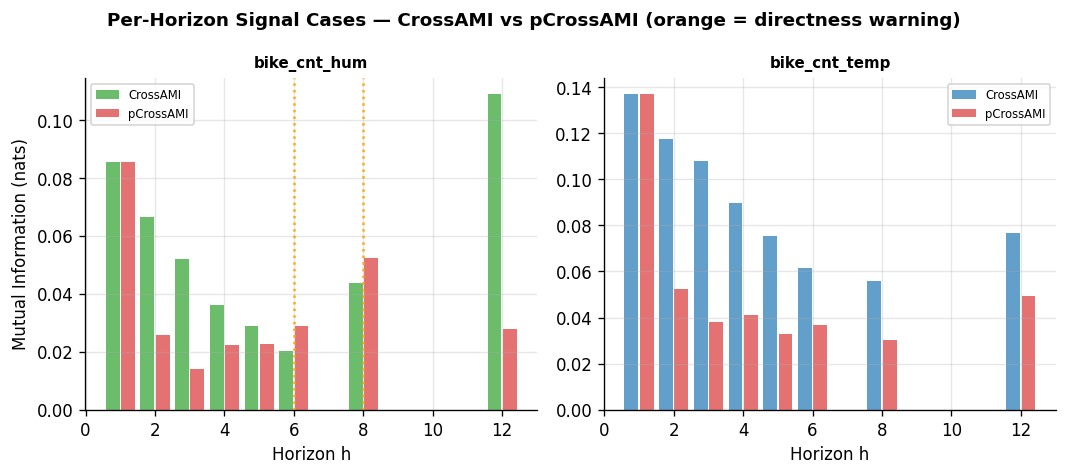

In [20]:
# Detail report: per-horizon directness for signal cases
signal_cases = summary_table[summary_table["mean_raw_cross_mi"] > NOISE_THRESHOLD][
    "case_id"
].tolist()

fig, axes = plt.subplots(1, len(signal_cases), figsize=(4.5 * len(signal_cases), 4), sharey=False)
axes = np.atleast_1d(axes)

for ax, case_id in zip(axes, signal_cases):
    subset = horizon_table[horizon_table["case_id"] == case_id].sort_values("horizon")
    color = COLOR_MAP.get(case_id, "#1f77b4")

    bar_raw = ax.bar(
        subset["horizon"] - 0.22,
        subset["raw_cross_mi"],
        0.4,
        label="CrossAMI",
        color=color,
        alpha=0.7,
    )
    bar_cond = ax.bar(
        subset["horizon"] + 0.22,
        subset["conditioned_cross_mi"],
        0.4,
        label="pCrossAMI",
        color="#d62728",
        alpha=0.65,
    )

    # Highlight warning horizons
    warn_hs = horizon_table[
        (horizon_table["case_id"] == case_id) & (horizon_table["warning_directness_gt_one"] == 1)
    ]["horizon"].tolist()
    for wh in warn_hs:
        ax.axvline(wh, color="orange", lw=1.5, ls=":", alpha=0.9)

    ax.set_title(case_id, fontsize=9, fontweight="bold")
    ax.set_xlabel("Horizon h")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Mutual Information (nats)")
fig.suptitle(
    "Per-Horizon Signal Cases — CrossAMI vs pCrossAMI (orange = directness warning)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 8b · Bring Your Own Data — Quick Start 🔧

```python
import numpy as np
from forecastability import ForecastabilityAnalyzerExog

# Your arrays — must be 1-D, same length
target = np.loadtxt("my_target.csv")
driver = np.loadtxt("my_driver.csv")

analyzer = ForecastabilityAnalyzerExog(n_surrogates=99, random_state=42)
cross_ami   = analyzer.compute_raw(    target, max_lag=12, method="mi", exog=driver)
p_cross_ami = analyzer.compute_partial(target, max_lag=12, method="mi", exog=driver)

import matplotlib.pyplot as plt
lags = range(1, 13)
plt.plot(lags, cross_ami,   label="CrossAMI   (total)")
plt.plot(lags, p_cross_ami, label="pCrossAMI  (direct)", ls="--")
plt.xlabel("Lead horizon h")
plt.legend()
plt.show()
```

For the **production rolling-origin pipeline** (recommended for real modelling decisions):

```python
from forecastability.pipeline import run_exogenous_rolling_origin_evaluation

result = run_exogenous_rolling_origin_evaluation(
    target, driver,
    case_id="my_case",
    target_name="my_target",
    exog_name="my_driver",
    horizons=[1, 2, 3, 6, 12],
    n_origins=10,
    random_state=42,
    n_surrogates=99,
)

print(result.raw_cross_mi_by_horizon)        # {1: 0.12, 2: 0.09, ...}
print(result.directness_ratio_by_horizon)    # {1: 0.71, 2: 0.65, ...}
```

## 9 · Conclusion & Call to Action 🚀

### Summary of findings

| Pair | CrossAMI? | pCrossAMI? | Verdict |
|------|-----------|------------|---------|
| Bike cnt ~ Temperature | ✅ Strong | ✅ Strong | Include in features |
| Bike cnt ~ Humidity | ✅ Moderate | ⚠️ Weaker | Include with caution |
| Bike cnt ~ Noise | ❌ At noise floor | ❌ | Correctly rejected |
| AAPL ~ SPY | ✅ Present | ⚠️ Partially mediated | Market beta effect |
| BTC ~ ETH | ✅ Present | ⚠️ Check warnings | Crypto co-movement |
| Equities/Crypto ~ Noise | ❌ At noise floor | ❌ | Correctly rejected |

### What this workflow gives you — for free

1. **No model assumptions** — kNN MI is nonlinear and model-free
2. **Horizon-specific signal map** — know *exactly* up to which lag each driver helps
3. **Direct vs proxy distinction** — pCrossAMI flags redundant features before training
4. **Rolling-origin robustness** — statistics computed on train windows only (no leakage)
5. **Built-in noise controls** — compare against synthetic null to calibrate thresholds

### Links

- 📖 **Paper:** [arXiv:2601.10006 — Dr. Peter Catt, *"The Knowable Future"*](https://arxiv.org/abs/2601.10006)
- 🐙 **Repository:** [github.com/AdamKrysztopa/dependence-forecastability](https://github.com/AdamKrysztopa/dependence-forecastability)
- 📓 **Notebook 1:** Canonical AMI vs pAMI cases
- 🐛 **Issues / PRs:** welcome!

---

> *If this helped you screen your multivariate features before modelling,
> please ⭐ the repo and share it.  The CrossAMI triage takes minutes and
> can save days of wasted modelling effort on uninformative drivers.*

---
*Notebook generated with `nbformat` · Python 3.11 · forecastability package*